# 새로운 데이터를 이용한 외부 타당화 (RQ2: 일반화 성능 평가)

## 목적
이 노트북은 연구의 **가장 엄격한 일반화 테스트**로, 기존 학습 데이터와 **완전히 다른 맥락**에서 수집된 새로운 피드백 데이터에 대해 4가지 분류 방법의 성능을 평가합니다.

## "완전히 새로운 맥락"이란?
기존 데이터와 새 데이터는 다음 측면에서 다릅니다:
- **다른 시기**: 기존 데이터와 다른 학기에 수집
- **다른 학생**: 기존 학습에 참여하지 않은 새로운 학생들
- **다른 문항**: 기존 8개 문항과 다른 과학 탐구 문항
- 이러한 변화를 교육 측정학에서 **도메인 이동(domain shift)**이라 하며, 모델의 실제 활용 가능성을 판단하는 핵심 기준입니다.

## 왜 중요한가?
교육 현장에서 자동 분류 시스템을 사용하려면, 특정 학습 데이터에만 최적화된 모델이 아닌 **새로운 상황에서도 안정적으로 작동하는 모델**이 필요합니다. 이 실험이 바로 그 검증 과정입니다.

## 분류 방식 (4가지)
1. **ML**: TF-IDF + 최적 ML 모델 (자동 선택)
2. **BERT**: 최적 사전학습 언어모델 (자동 선택)
3. **LLM**: GPT-4o + 최적 프롬프트 (자동 선택)
4. **Hybrid**: LLM 1차 분류 후 Label 3,4,5에 대해 BERT 재분류

## 주요 출력
- 3회 반복 실행 결과 및 재현율 분석
- 다수결 투표 기반 최종 레이블
- 사람 라벨링 데이터 대비 성능 평가

## 1. 환경 설정

In [ ]:
import sys
import os
import json
import glob
import warnings
import platform
import time
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Tuple, Optional
from collections import Counter
from scipy import stats as scipy_stats

import numpy as np
import pandas as pd
import joblib
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# 프로젝트 경로 설정
PROJECT_DIR = Path('..')
ML_DIR = PROJECT_DIR / '2_ml'
BERT_DIR = PROJECT_DIR / '3_bert'
LLM_DIR = PROJECT_DIR / '4_llm'
HYBRID_DIR = PROJECT_DIR / '05_hybrid'
OUTPUT_DIR = Path('./results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# LLM src 경로 추가
if str(LLM_DIR / 'src') not in sys.path:
    sys.path.insert(0, str(LLM_DIR / 'src'))

print(f"프로젝트 디렉토리: {PROJECT_DIR}")
print(f"결과 저장 디렉토리: {OUTPUT_DIR}")
print(f"Python: {sys.version.split()[0]}")
print(f"실행 시작: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

---
## 2. 최고 성능 모델 자동 탐색

저장된 실험 결과 CSV 파일을 읽어 각 방식별 최고 성능 모델을 **자동으로** 선택합니다.

In [102]:
# ============================================================
# 모델 선택 기준 (변경 가능)
# ============================================================
SELECTION_METRIC = 'f1_macro'  # 'f1_macro', 'accuracy', 'kappa' 중 선택

print(f"모델 선택 기준: {SELECTION_METRIC}")

모델 선택 기준: f1_macro


### 2.1 ML 최고 모델 탐색

In [103]:
# ============================================================
# ML 모델 자동 탐색
# ============================================================

# CSV 모델명 → joblib 파일명 매핑
ML_NAME_MAP = {
    'SVM (Linear)': 'SVM-L', 'SVM (RBF)': 'SVM-RBF',
    'Stacking': 'Stacking', 'Random Forest': 'RF',
    'Soft Voting': 'Soft_Voting', 'Hard Voting': 'Hard_Voting',
    'XGBoost': 'XGB', 'LightGBM': 'LGBM',
    'Logistic Regression': 'LR', 'K-Nearest Neighbors': 'KNN',
    'Decision Tree': 'DT', 'Gradient Boosting': 'GB',
    'Multinomial NB': 'MNB', 'Complement NB': 'CNB',
}
ML_NAME_MAP_INV = {v: k for k, v in ML_NAME_MAP.items()}

# 메트릭 컬럼 매핑
ML_METRIC_MAP = {'f1_macro': 'F1_Macro', 'accuracy': 'Accuracy', 'kappa': 'Kappa'}

ml_metrics_path = ML_DIR / 'results' / 'test_results.csv'
ml_df = pd.read_csv(ml_metrics_path, encoding='utf-8-sig')

metric_col = ML_METRIC_MAP[SELECTION_METRIC]
best_ml_row = ml_df.loc[ml_df[metric_col].idxmax()]
best_ml_display_name = best_ml_row['Model']
best_ml_joblib_name = ML_NAME_MAP.get(best_ml_display_name, best_ml_display_name)

# joblib 파일 존재 확인
ml_model_dir = ML_DIR / 'results' / 'models'
ml_clf_path = ml_model_dir / 'classifiers' / f'{best_ml_joblib_name}.joblib'
assert ml_clf_path.exists(), f"ML 모델 파일을 찾을 수 없습니다: {ml_clf_path}"

best_ml_info = {
    'display_name': best_ml_display_name,
    'joblib_name': best_ml_joblib_name,
    'model_dir': str(ml_model_dir),
    'accuracy': best_ml_row['Accuracy'],
    'f1_macro': best_ml_row['F1_Macro'],
    'kappa': best_ml_row['Kappa'],
}

print(f"[ML] 최고 모델: {best_ml_display_name} ({best_ml_joblib_name})")
print(f"  Accuracy: {best_ml_info['accuracy']:.4f}")
print(f"  F1 Macro: {best_ml_info['f1_macro']:.4f}")
print(f"  Kappa:    {best_ml_info['kappa']:.4f}")
print(f"\n전체 ML 모델 성능:")
display(ml_df.sort_values(metric_col, ascending=False).head(5))

[ML] 최고 모델: SVM (Linear) (SVM-L)
  Accuracy: 0.8413
  F1 Macro: 0.7755
  Kappa:    0.7979

전체 ML 모델 성능:


,Model,Accuracy,F1_Macro,F1_Weighted,Kappa
0,SVM (Linear),0.841346,0.775472,0.848990,0.797899
1,Stacking,0.841346,0.767294,0.852886,0.799047
2,Random Forest,0.826923,0.752956,0.839575,0.778557
3,Soft Voting,0.826923,0.746777,0.841700,0.780027
4,Hard Voting,0.812500,0.741380,0.829857,0.761977


### 2.2 BERT 최고 모델 탐색

In [104]:
# ============================================================
# BERT 모델 자동 탐색
# ============================================================
BERT_METRIC_MAP = {'f1_macro': 'macro_f1', 'accuracy': 'accuracy', 'kappa': 'kappa'}

# 1) model_ranking.csv에서 최고 모델 타입 확인
bert_ranking_path = BERT_DIR / 'results' / 'final_experiment' / 'model_ranking.csv'
bert_ranking_df = pd.read_csv(bert_ranking_path)
best_bert_model_type = bert_ranking_df.loc[bert_ranking_df['rank'] == 1, 'model'].values[0]

# 2) test_results.csv에서 해당 모델의 최고 seed 찾기
bert_test_path = BERT_DIR / 'results' / 'final_experiment' / 'test_results.csv'
bert_test_df = pd.read_csv(bert_test_path)
bert_best_model_df = bert_test_df[bert_test_df['model'] == best_bert_model_type]

metric_col = BERT_METRIC_MAP[SELECTION_METRIC]
best_bert_row = bert_best_model_df.loc[bert_best_model_df[metric_col].idxmax()]
best_bert_seed = int(best_bert_row['train_seed'])

# 3) 모델 경로 결정 (final_experiment 우선, 없으면 기본 models)
bert_final_model_dir = BERT_DIR / 'results' / 'final_experiment' / 'models'
bert_model_name_with_seed = f"{best_bert_model_type}_seed{best_bert_seed}"

if (bert_final_model_dir / bert_model_name_with_seed).exists():
    best_bert_model_dir = str(bert_final_model_dir)
    best_bert_model_name = bert_model_name_with_seed
else:
    best_bert_model_dir = str(BERT_DIR / 'results' / 'models')
    best_bert_model_name = best_bert_model_type
    print(f"  ⚠ final_experiment 모델 없음, 기본 모델 사용: {best_bert_model_name}")

best_bert_info = {
    'model_type': best_bert_model_type,
    'seed': best_bert_seed,
    'model_dir': best_bert_model_dir,
    'model_name': best_bert_model_name,
    'accuracy': best_bert_row['accuracy'],
    'f1_macro': best_bert_row['macro_f1'],
    'kappa': best_bert_row['kappa'],
}

print(f"[BERT] 최고 모델: {best_bert_model_name}")
print(f"  Accuracy: {best_bert_info['accuracy']:.4f}")
print(f"  F1 Macro: {best_bert_info['f1_macro']:.4f}")
print(f"  Kappa:    {best_bert_info['kappa']:.4f}")
print(f"  경로:     {best_bert_model_dir}/{best_bert_model_name}")
print(f"\n전체 BERT 모델 성능 (seed별):")
display(bert_test_df.sort_values(metric_col, ascending=False))

[BERT] 최고 모델: KLUE-BERT_seed44
  Accuracy: 0.9663
  F1 Macro: 0.9409
  Kappa:    0.9563
  경로:     <PROJECT_ROOT>/01_Analysis/02_BERT/results/final_experiment/models/KLUE-BERT_seed44

전체 BERT 모델 성능 (seed별):


,model,train_seed,test_seed,accuracy,macro_f1,weighted_f1,kappa
5,KLUE-BERT,44,44,0.966346,0.940875,0.965958,0.956274
6,KLUE-RoBERTa,42,42,0.942308,0.921152,0.942172,0.925222
3,KLUE-BERT,42,42,0.923077,0.903939,0.923215,0.900308
8,KLUE-RoBERTa,44,44,0.939904,0.902517,0.939496,0.922007
2,mBERT,44,44,0.927885,0.894283,0.926972,0.906319
4,KLUE-BERT,43,43,0.930288,0.893619,0.927977,0.909146
1,mBERT,43,43,0.925481,0.892553,0.923870,0.903062
7,KLUE-RoBERTa,43,43,0.927885,0.889233,0.925278,0.905932
0,mBERT,42,42,0.913462,0.878928,0.914282,0.888143
11,KoELECTRA,44,44,0.908654,0.861829,0.905585,0.880996


### 2.3 LLM 최고 모델 + 프롬프트 탐색

In [105]:
# ============================================================
# LLM 모델+프롬프트 자동 탐색 (final + other experiment 통합)
# ============================================================
UNIFIED_METRIC_MAP = {'f1_macro': 'F1_Macro', 'accuracy': 'Accuracy', 'kappa': 'Kappa'}
metric_col = UNIFIED_METRIC_MAP[SELECTION_METRIC]

# --- 1) final_experiment: combination_summary CSV ---
llm_final_dir = LLM_DIR / 'results' / 'final_experiment' / 'summary'
llm_final_files = sorted(llm_final_dir.glob('combination_summary_*.csv'))

dfs = []
if llm_final_files:
    df_final = pd.read_csv(llm_final_files[-1])
    # 컬럼명 통일
    df_final = df_final.rename(columns={
        'Acc_Mean': 'Accuracy', 'F1_Mean': 'F1_Macro', 'Kappa_Mean': 'Kappa'
    })
    df_final['Source'] = 'final_experiment'
    dfs.append(df_final[['Model', 'Prompt', 'Accuracy', 'F1_Macro', 'Kappa', 'Source']])

# --- 2) other_experiment: combined_summary CSV ---
llm_other_dir = LLM_DIR / 'results' / 'other_experiment'
llm_other_files = sorted(llm_other_dir.glob('combined_summary_*.csv'))

if llm_other_files:
    df_other = pd.read_csv(llm_other_files[-1])
    df_other['Source'] = 'other_experiment'
    dfs.append(df_other[['Model', 'Prompt', 'Accuracy', 'F1_Macro', 'Kappa', 'Source']])

assert dfs, "LLM 실험 결과 파일을 찾을 수 없습니다."

# --- 3) 통합 후 중복 제거 (같은 Model+Prompt → other_experiment 우선) ---
llm_summary_df = pd.concat(dfs, ignore_index=True)
llm_summary_df = llm_summary_df.sort_values('Source', ascending=False)  # other 우선
llm_summary_df = llm_summary_df.drop_duplicates(subset=['Model', 'Prompt'], keep='first')
llm_summary_df = llm_summary_df.sort_values(metric_col, ascending=False).reset_index(drop=True)

# --- 4) 최고 조합 선택 ---
best_llm_row = llm_summary_df.iloc[0]

best_llm_info = {
    'model': best_llm_row['Model'],
    'prompt': best_llm_row['Prompt'],
    'accuracy': best_llm_row['Accuracy'],
    'f1_macro': best_llm_row['F1_Macro'],
    'kappa': best_llm_row['Kappa'],
}

# OpenAI 모델명 매핑
LLM_API_MODEL_MAP = {
    'GPT-4o': 'gpt-4o',
    'GPT-4o mini': 'gpt-4o-mini',
}
best_llm_api_model = LLM_API_MODEL_MAP.get(best_llm_info['model'], best_llm_info['model'])

print(f"[LLM] 최고 조합: {best_llm_info['model']} + {best_llm_info['prompt']}")
print(f"  API 모델명: {best_llm_api_model}")
print(f"  Accuracy: {best_llm_info['accuracy']:.4f}")
print(f"  F1 Macro: {best_llm_info['f1_macro']:.4f}")
print(f"  Kappa:    {best_llm_info['kappa']:.4f}")
print(f"  출처:     {best_llm_row['Source']}")
print(f"\n전체 LLM 조합 성능 ({len(llm_summary_df)}개):")
display(llm_summary_df)

[LLM] 최고 조합: GPT-4o + P4_CoT_Few_Context
  API 모델명: gpt-4o
  Accuracy: 0.6442
  F1 Macro: 0.6870
  Kappa:    0.5593
  출처:     other_experiment

전체 LLM 조합 성능 (15개):


,Model,Prompt,Accuracy,F1_Macro,Kappa,Source
0,GPT-4o,P4_CoT_Few_Context,0.644231,0.686980,0.559306,other_experiment
1,GPT-4o,P7_P4_labeled_reason,0.644231,0.683648,0.557784,other_experiment
2,GPT-4o,P2_few-shot_cot_v3,0.632212,0.668990,0.550496,other_experiment
3,GPT-4o,P6_v8_label5_boost,0.680288,0.665105,0.593365,other_experiment
4,GPT-4o,P2_few-shot_cot_v8,0.665865,0.639988,0.574404,other_experiment
5,GPT-4o,P2_few-shot_cot_v7,0.663462,0.636673,0.570657,other_experiment
6,GPT-4o,P2_few-shot_cot_v6,0.663462,0.610468,0.569530,other_experiment
7,Solar-Pro3,P2_few-shot_cot_v3,0.574519,0.584915,0.477669,other_experiment
8,Solar-Pro3,P2_few-shot_cot_v6,0.644231,0.567916,0.553836,other_experiment
9,GPT-4o,P3_CoT_Few_Context,0.574519,0.562029,0.466083,other_experiment


### 2.4 탐색 결과 요약

In [106]:
# ============================================================
# 자동 탐색 결과 요약
# ============================================================
summary_data = [
    {
        '방식': 'ML',
        '선택 모델': best_ml_info['display_name'],
        'Accuracy': best_ml_info['accuracy'],
        'F1 Macro': best_ml_info['f1_macro'],
        'Kappa': best_ml_info['kappa'],
    },
    {
        '방식': 'BERT',
        '선택 모델': best_bert_info['model_name'],
        'Accuracy': best_bert_info['accuracy'],
        'F1 Macro': best_bert_info['f1_macro'],
        'Kappa': best_bert_info['kappa'],
    },
    {
        '방식': 'LLM',
        '선택 모델': f"{best_llm_info['model']} + {best_llm_info['prompt']}",
        'Accuracy': best_llm_info['accuracy'],
        'F1 Macro': best_llm_info['f1_macro'],
        'Kappa': best_llm_info['kappa'],
    },
    {
        '방식': 'Hybrid',
        '선택 모델': f"{best_llm_info['model']}({best_llm_info['prompt']}) + {best_bert_info['model_name']}",
        'Accuracy': '-',
        'F1 Macro': '-',
        'Kappa': '-',
    },
]

summary_df = pd.DataFrame(summary_data)
print("=" * 70)
print(f"자동 탐색 결과 요약 (선택 기준: {SELECTION_METRIC})")
print("=" * 70)
display(summary_df)
print("\n* Hybrid 성능은 LLM+BERT 조합이므로 별도 벤치마크 참조")

자동 탐색 결과 요약 (선택 기준: f1_macro)


,방식,선택 모델,Accuracy,F1 Macro,Kappa
0,ML,SVM (Linear),0.841346,0.775472,0.797899
1,BERT,KLUE-BERT_seed44,0.966346,0.940875,0.956274
2,LLM,GPT-4o + P4_CoT_Few_Context,0.644231,0.68698,0.559306
3,Hybrid,GPT-4o(P4_CoT_Few_Context) + KLUE-BERT_seed44,-,-,-



* Hybrid 성능은 LLM+BERT 조합이므로 별도 벤치마크 참조


---
## 3. 데이터 로드

In [ ]:
# ============================================================
# 데이터 설정 (필요시 수정)
# ============================================================
DATA_CONFIG = {
    "data_path": "../data/feedback_data.xlsx",  # new_context 시트
    "text_column": "feedback_text",
    "id_column": "id",
}

print("데이터 설정:")
for k, v in DATA_CONFIG.items():
    print(f"  {k}: {v}")

In [108]:
# 데이터 로드
data_path = Path(DATA_CONFIG["data_path"])

if data_path.suffix == '.csv':
    new_df = pd.read_csv(data_path)
elif data_path.suffix in ['.xlsx', '.xls']:
    new_df = pd.read_excel(data_path, sheet_name='new_context').drop(columns=['label'])
else:
    raise ValueError(f"지원하지 않는 파일 형식: {data_path.suffix}")

print(f"데이터 로드 완료: {len(new_df)}개 샘플")
print(f"컬럼: {list(new_df.columns)}")

# 필수 컬럼 확인
text_col = DATA_CONFIG["text_column"]
id_col = DATA_CONFIG["id_column"]

if text_col not in new_df.columns:
    possible_text_cols = [c for c in new_df.columns if 'text' in c.lower() or 'feedback' in c.lower()]
    if possible_text_cols:
        text_col = possible_text_cols[0]
        print(f"텍스트 컬럼 자동 선택: '{text_col}'")
    else:
        raise ValueError(f"텍스트 컬럼을 찾을 수 없습니다. 컬럼 목록: {list(new_df.columns)}")

if id_col not in new_df.columns:
    new_df['id'] = range(1, len(new_df) + 1)
    id_col = 'id'
    print(f"ID 컬럼 자동 생성")

texts = new_df[text_col].tolist()
ids = new_df[id_col].astype(str).tolist()

print(f"\n처음 5개 샘플:")
display(new_df[[id_col, text_col]].head())

---
## 4. 분류 함수 정의

### 4.1 ML 분류기

In [109]:
# ============================================================
# ML 모델 로드 및 분류 함수
# ============================================================

def custom_tokenizer(text):
    """이미 토큰화된 텍스트를 공백으로 분리"""
    return text.split() if text else []

def identity_preprocessor(text):
    """전처리 없이 텍스트 그대로 반환"""
    return text

def load_ml_models(model_dir):
    model_dir = Path(model_dir)
    models = {}
    models['vectorizer_v1'] = joblib.load(model_dir / 'vectorizer_v1.joblib')
    models['vectorizer_v2'] = joblib.load(model_dir / 'vectorizer_v2.joblib')
    models['label_encoder'] = joblib.load(model_dir / 'label_encoder.joblib')
    clf_dir = model_dir / 'classifiers'
    models['classifiers'] = {}
    for f in clf_dir.glob('*.joblib'):
        models['classifiers'][f.stem] = joblib.load(f)
    return models

def predict_with_ml(texts, models, classifier_name):
    vectorizer = models['vectorizer_v1']
    classifier = models['classifiers'][classifier_name]
    label_encoder = models['label_encoder']
    texts = [str(t) if pd.notna(t) else "" for t in texts]
    X = vectorizer.transform(texts)
    y_pred_encoded = classifier.predict(X)
    y_pred = label_encoder.inverse_transform(y_pred_encoded)
    return y_pred.tolist()

print("ML 분류 함수 정의 완료")

ML 분류 함수 정의 완료


### 4.2 BERT 분류기

In [110]:
# ============================================================
# BERT 분류기 클래스
# ============================================================
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()

class BERTClassifier:
    def __init__(self, model_dir, model_name, device=None, max_length=128):
        self.model_path = Path(model_dir) / model_name
        self.model_name = model_name
        self.device = device or get_device()
        self.max_length = max_length
        print(f"BERT 모델 로딩: {model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(self.model_path)
        self.model.to(self.device)
        self.model.eval()
        print(f"BERT 모델 로드 완료 (Device: {self.device})")

    def predict_batch(self, texts, batch_size=32):
        results = []
        texts = [str(t) if pd.notna(t) else "" for t in texts]
        for i in tqdm(range(0, len(texts), batch_size), desc="BERT 분류"):
            batch_texts = texts[i:i + batch_size]
            encodings = self.tokenizer(
                batch_texts, add_special_tokens=True,
                max_length=self.max_length, padding='max_length',
                truncation=True, return_tensors='pt'
            )
            input_ids = encodings['input_ids'].to(self.device)
            attention_mask = encodings['attention_mask'].to(self.device)
            with torch.no_grad():
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                probs = torch.softmax(outputs.logits, dim=1)
                preds = torch.argmax(outputs.logits, dim=1)
            for pred, prob in zip(preds.cpu().numpy(), probs.cpu().numpy()):
                results.append({'label': int(pred), 'confidence': float(prob[pred])})
        return results

    def unload(self):
        del self.model
        del self.tokenizer
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        elif torch.cuda.is_available():
            torch.cuda.empty_cache()
        print(f"BERT 모델 메모리 해제: {self.model_name}")

print(f"BERT 분류 클래스 정의 완료 (Device: {DEVICE})")

BERT 분류 클래스 정의 완료 (Device: mps)


### 4.3 LLM 분류기

In [111]:
# ============================================================
# LLM 클라이언트 초기화
# ============================================================
from dotenv import load_dotenv

load_dotenv(LLM_DIR / '.env')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
print(f"OPENAI_API_KEY 설정됨: {bool(OPENAI_API_KEY)}")

if OPENAI_API_KEY:
    from openai import OpenAI
    client = OpenAI()
    print("OpenAI 클라이언트 초기화 완료")
else:
    client = None
    print("OPENAI_API_KEY가 없습니다. LLM/Hybrid 분류는 건너뜁니다.")

OPENAI_API_KEY 설정됨: True
OpenAI 클라이언트 초기화 완료


In [112]:
# ============================================================
# 프롬프트 로드
# ============================================================
from config import Config
from prompt_loader import PromptLoader, Prompt

config = Config()
prompt_loader = PromptLoader(config.prompts_dir)

SELECTED_LLM_PROMPT = best_llm_info['prompt']
prompt = prompt_loader.load(SELECTED_LLM_PROMPT)

print(f"선택된 프롬프트: {SELECTED_LLM_PROMPT} (v{prompt.version})")

선택된 프롬프트: P4_CoT_Few_Context (vP4_v1.0)


In [113]:
# ============================================================
# LLM 분류 함수 (개별 처리)
# ============================================================
MAX_RETRIES = 3
RETRY_DELAY = 2

failure_log = []


def classify_all_with_llm(texts, ids, prompt, model="gpt-4o", temperature=0, max_tokens=150):
    """전체 텍스트를 1개씩 개별 분류"""
    global failure_log
    failure_log = []
    results = []

    for text, sid in tqdm(zip(texts, ids), total=len(texts), desc="LLM 분류"):
        result = classify_single_with_llm(text, sid, prompt, model, temperature, max_tokens)
        results.append(result)

    return results


def classify_single_with_llm(text, sample_id, prompt, model="gpt-4o", temperature=0, max_tokens=150):
    """단일 텍스트 LLM 분류 (재시도 포함)"""
    global failure_log
    text = str(text) if pd.notna(text) else ""
    user_prompt = prompt.format_user_prompt(text)

    for retry in range(MAX_RETRIES):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": prompt.system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=temperature,
                max_tokens=max_tokens
            )
            raw_response = response.choices[0].message.content.strip()
            label = parse_single_response(raw_response)
            if label is not None and 0 <= label <= 6:
                return {'label': label, 'success': True}
            elif retry < MAX_RETRIES - 1:
                time.sleep(RETRY_DELAY)
        except Exception as e:
            if retry < MAX_RETRIES - 1:
                time.sleep(RETRY_DELAY)

    failure_log.append({
        'id': sample_id, 'text': text[:100],
        'reason': 'final_failure', 'detail': '최대 재시도 초과'
    })
    return {'label': None, 'success': False}


def parse_single_response(text):
    """단일 응답 파싱"""
    import re
    try:
        if '{' in text and '}' in text:
            start, end = text.find('{'), text.rfind('}') + 1
            result = json.loads(text[start:end])
            label = int(result.get('label', -1))
        else:
            numbers = re.findall(r'\d+', text)
            label = int(numbers[0]) if numbers else -1
        return label if 0 <= label <= 6 else None
    except:
        return None


print("LLM 분류 함수 정의 완료 (개별 처리 모드)")

LLM 분류 함수 정의 완료 (개별 처리 모드)


## 분류 실행 및 재현율 분석

아래에서 4가지 방식(ML, BERT, LLM, Hybrid)으로 새 데이터를 3회 반복 분류합니다. 반복 실행은 모델의 **재현율(reproducibility)**을 검증하기 위한 것으로, 동일한 데이터에 대해 일관된 결과를 산출하는지 확인합니다.

> **재현율이 중요한 이유**: 교육 현장에서 자동 분류 시스템을 활용할 때, 같은 피드백에 대해 실행할 때마다 다른 결과가 나오면 신뢰할 수 없습니다.

In [114]:
# ============================================================
# 실행 설정
# ============================================================
N_RUNS = 1  # 반복 횟수

print(f"반복 횟수: {N_RUNS}")
print(f"데이터 수: {len(texts)}")
print(f"\n사용 모델:")
print(f"  ML:     {best_ml_info['joblib_name']}")
print(f"  BERT:   {best_bert_info['model_name']}")
print(f"  LLM:    {best_llm_api_model} + {SELECTED_LLM_PROMPT}")
print(f"  Hybrid: LLM 1차 -> BERT 재분류 (Label 3,4,5)")

반복 횟수: 1
데이터 수: 193

사용 모델:
  ML:     SVM-L
  BERT:   KLUE-BERT_seed44
  LLM:    gpt-4o + P4_CoT_Few_Context
  Hybrid: LLM 1차 -> BERT 재분류 (Label 3,4,5)


In [115]:
# ============================================================
# 모델 로드 (1회만)
# ============================================================
print("모델 로딩...")

# ML 모델 로드
ml_models = load_ml_models(best_ml_info['model_dir'])
print(f"  ML 모델 로드 완료: {best_ml_info['joblib_name']}")

# BERT 모델 로드
bert_classifier = BERTClassifier(
    model_dir=best_bert_info['model_dir'],
    model_name=best_bert_info['model_name'],
    device=DEVICE,
    max_length=128
)
print(f"\n모든 모델 로드 완료!")

모델 로딩...
  ML 모델 로드 완료: SVM-L
BERT 모델 로딩: KLUE-BERT_seed44...
BERT 모델 로드 완료 (Device: mps)

모든 모델 로드 완료!


In [116]:
# ============================================================
# 3회 반복 실행
# ============================================================
all_predictions = {'ML': [], 'BERT': [], 'LLM': [], 'Hybrid': []}

HYBRID_TARGET_LABELS = [3, 4, 5]

for run_idx in range(N_RUNS):
    print(f"\n{'='*60}")
    print(f"Run {run_idx + 1}/{N_RUNS}")
    print(f"{'='*60}")

    # --- ML ---
    print(f"\n  [ML] {best_ml_info['joblib_name']}")
    ml_preds = predict_with_ml(texts, ml_models, classifier_name=best_ml_info['joblib_name'])
    all_predictions['ML'].append(ml_preds)
    print(f"  ML 완료: {len(ml_preds)}개")

    # --- BERT ---
    print(f"\n  [BERT] {best_bert_info['model_name']}")
    bert_results = bert_classifier.predict_batch(texts, batch_size=32)
    bert_preds = [r['label'] for r in bert_results]
    all_predictions['BERT'].append(bert_preds)
    print(f"  BERT 완료: {len(bert_preds)}개")

    # --- LLM (개별 처리) ---
    if client is not None:
        print(f"\n  [LLM] {best_llm_api_model} + {SELECTED_LLM_PROMPT} (개별 처리)")
        llm_results = classify_all_with_llm(
            texts=texts, ids=ids, prompt=prompt,
            model=best_llm_api_model,
            temperature=0, max_tokens=150
        )
        llm_preds = [r['label'] for r in llm_results]
        n_success = sum(1 for r in llm_results if r['success'])
        n_fail = sum(1 for r in llm_results if not r['success'])
        print(f"  LLM 완료: 성공 {n_success}, 실패 {n_fail}")
    else:
        llm_preds = [None] * len(texts)
        llm_results = [{'label': None, 'success': False}] * len(texts)
        print("  LLM 건너뜀 (API 키 없음)")
    all_predictions['LLM'].append(llm_preds)

    # --- Hybrid (LLM 결과 재사용 + BERT 재분류) ---
    if client is not None:
        print(f"\n  [Hybrid] LLM 1차 -> BERT 재분류 (Label {HYBRID_TARGET_LABELS})")
        hybrid_preds = list(llm_preds)  # LLM 결과 복사

        target_indices = [i for i, label in enumerate(hybrid_preds) if label in HYBRID_TARGET_LABELS]
        target_texts = [texts[i] for i in target_indices]

        if target_texts:
            bert_reclass = bert_classifier.predict_batch(target_texts, batch_size=32)
            for idx, br in zip(target_indices, bert_reclass):
                hybrid_preds[idx] = br['label']

        n_reclass = len(target_indices)
        print(f"  Hybrid 완료: LLM={len(texts)-n_reclass}, BERT 재분류={n_reclass}")
    else:
        hybrid_preds = [None] * len(texts)
        print("  Hybrid 건너뜀 (API 키 없음)")
    all_predictions['Hybrid'].append(hybrid_preds)

print(f"\n{'='*60}")
print(f"전체 {N_RUNS}회 반복 실행 완료!")
print(f"{'='*60}")


Run 1/1

  [ML] SVM-L
  ML 완료: 193개

  [BERT] KLUE-BERT_seed44


BERT 분류: 100%|██████████| 7/7 [00:00<00:00, 10.31it/s]


  BERT 완료: 193개

  [LLM] gpt-4o + P4_CoT_Few_Context (개별 처리)


LLM 분류: 100%|██████████| 193/193 [02:24<00:00,  1.34it/s]


  LLM 완료: 성공 193, 실패 0

  [Hybrid] LLM 1차 -> BERT 재분류 (Label [3, 4, 5])


BERT 분류: 100%|██████████| 2/2 [00:00<00:00,  2.62it/s]

  Hybrid 완료: LLM=148, BERT 재분류=45

전체 1회 반복 실행 완료!


In [117]:
# BERT 메모리 해제
bert_classifier.unload()
bert_classifier = None

BERT 모델 메모리 해제: KLUE-BERT_seed44


---
## 6. 재현율(Reproducibility) 분석

In [118]:
# ============================================================
# 재현율 분석 함수
# ============================================================
from sklearn.metrics import cohen_kappa_score

def compute_pairwise_agreement(run_preds_list):
    """Run 간 쌍별 일치율 및 Cohen's Kappa 계산"""
    n_runs = len(run_preds_list)
    results = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            preds_i = run_preds_list[i]
            preds_j = run_preds_list[j]
            # None 제외
            valid = [(a, b) for a, b in zip(preds_i, preds_j) if a is not None and b is not None]
            if not valid:
                continue
            a_vals, b_vals = zip(*valid)
            agreement = sum(1 for a, b in valid if a == b) / len(valid)
            kappa = cohen_kappa_score(a_vals, b_vals)
            results.append({
                'Run_pair': f'Run{i+1} vs Run{j+1}',
                'Agreement': agreement,
                'Kappa': kappa,
                'N_valid': len(valid),
            })
    return results


def compute_fleiss_kappa(run_preds_list, n_categories=7):
    """Fleiss' Kappa 계산 (3회 이상)"""
    n_runs = len(run_preds_list)
    n_samples = len(run_preds_list[0])

    # 유효한 샘플만 (모든 run에서 None이 아닌)
    valid_indices = []
    for idx in range(n_samples):
        if all(run_preds_list[r][idx] is not None for r in range(n_runs)):
            valid_indices.append(idx)

    if not valid_indices:
        return None

    n_valid = len(valid_indices)
    table = np.zeros((n_valid, n_categories), dtype=int)

    for row, idx in enumerate(valid_indices):
        for r in range(n_runs):
            cat = run_preds_list[r][idx]
            if 0 <= cat < n_categories:
                table[row, cat] += 1

    N = n_valid
    n = n_runs
    p_j = table.sum(axis=0) / (N * n)
    P_i = (np.sum(table ** 2, axis=1) - n) / (n * (n - 1))
    P_bar = np.mean(P_i)
    P_e = np.sum(p_j ** 2)

    if P_e == 1.0:
        return 1.0
    return (P_bar - P_e) / (1 - P_e)


def compute_identical_rate(run_preds_list):
    """모든 run에서 동일한 예측 비율"""
    n_samples = len(run_preds_list[0])
    n_identical = 0
    n_valid = 0
    for idx in range(n_samples):
        vals = [run_preds_list[r][idx] for r in range(len(run_preds_list))]
        if all(v is not None for v in vals):
            n_valid += 1
            if len(set(vals)) == 1:
                n_identical += 1
    return n_identical / n_valid if n_valid > 0 else None


print("재현율 분석 함수 정의 완료")

재현율 분석 함수 정의 완료


In [119]:
# ============================================================
# 재현율 계산
# ============================================================
print("=" * 60)
print("재현율(Reproducibility) 분석")
print("=" * 60)

reproducibility_results = {}

for method in ['ML', 'BERT', 'LLM', 'Hybrid']:
    run_preds = all_predictions[method]
    print(f"\n--- {method} ---")

    # 쌍별 일치율
    pairwise = compute_pairwise_agreement(run_preds)
    if pairwise:
        pair_df = pd.DataFrame(pairwise)
        display(pair_df)

    # Fleiss' Kappa
    fleiss = compute_fleiss_kappa(run_preds)
    print(f"Fleiss' Kappa: {fleiss:.4f}" if fleiss is not None else "Fleiss' Kappa: N/A")

    # 전체 동일 비율
    identical = compute_identical_rate(run_preds)
    print(f"전체 동일 예측 비율: {identical:.4f}" if identical is not None else "전체 동일 예측 비율: N/A")

    reproducibility_results[method] = {
        'pairwise': pairwise,
        'fleiss_kappa': fleiss,
        'identical_rate': identical,
    }

재현율(Reproducibility) 분석

--- ML ---
Fleiss' Kappa: nan
전체 동일 예측 비율: 1.0000

--- BERT ---
Fleiss' Kappa: nan
전체 동일 예측 비율: 1.0000

--- LLM ---
Fleiss' Kappa: nan
전체 동일 예측 비율: 1.0000

--- Hybrid ---
Fleiss' Kappa: nan
전체 동일 예측 비율: 1.0000


In [120]:
# ============================================================
# 재현율 요약 테이블
# ============================================================
repro_summary = []
for method, res in reproducibility_results.items():
    avg_agreement = np.mean([p['Agreement'] for p in res['pairwise']]) if res['pairwise'] else None
    avg_kappa = np.mean([p['Kappa'] for p in res['pairwise']]) if res['pairwise'] else None
    repro_summary.append({
        '방식': method,
        '평균 일치율': f"{avg_agreement:.4f}" if avg_agreement is not None else 'N/A',
        '평균 Cohen Kappa': f"{avg_kappa:.4f}" if avg_kappa is not None else 'N/A',
        'Fleiss Kappa': f"{res['fleiss_kappa']:.4f}" if res['fleiss_kappa'] is not None else 'N/A',
        '동일 예측 비율': f"{res['identical_rate']:.4f}" if res['identical_rate'] is not None else 'N/A',
    })

repro_summary_df = pd.DataFrame(repro_summary)
print("\n=== 재현율 요약 ===")
display(repro_summary_df)


=== 재현율 요약 ===


,방식,평균 일치율,평균 Cohen Kappa,Fleiss Kappa,동일 예측 비율
0,ML,N/A,N/A,nan,1.0000
1,BERT,N/A,N/A,nan,1.0000
2,LLM,N/A,N/A,nan,1.0000
3,Hybrid,N/A,N/A,nan,1.0000


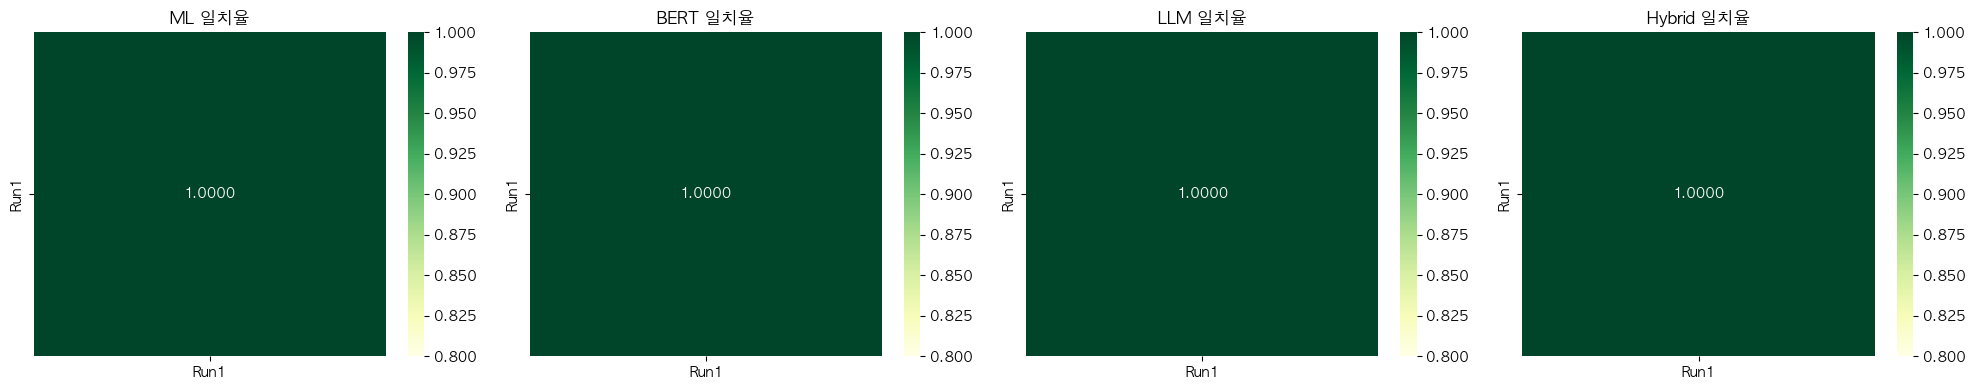

In [121]:
# ============================================================
# 재현율 시각화
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# 방식별 쌍간 일치율 히트맵
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, method in zip(axes, ['ML', 'BERT', 'LLM', 'Hybrid']):
    run_preds = all_predictions[method]
    n_runs = len(run_preds)
    matrix = np.ones((n_runs, n_runs))

    for pw in reproducibility_results[method]['pairwise']:
        pair = pw['Run_pair']
        i = int(pair.split(' vs ')[0].replace('Run', '')) - 1
        j = int(pair.split(' vs ')[1].replace('Run', '')) - 1
        matrix[i, j] = pw['Agreement']
        matrix[j, i] = pw['Agreement']

    sns.heatmap(matrix, annot=True, fmt='.4f', cmap='YlGn',
                xticklabels=[f'Run{i+1}' for i in range(n_runs)],
                yticklabels=[f'Run{i+1}' for i in range(n_runs)],
                vmin=0.8, vmax=1.0, ax=ax)
    ax.set_title(f'{method} 일치율')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'reproducibility_heatmap_{timestamp}.png', dpi=150)
plt.show()

---
## 7. 최종 결과 정리 및 저장

3회 반복 결과를 **다수결 투표(majority vote)**로 최종 레이블을 결정합니다.

In [122]:
# ============================================================
# 다수결 투표로 최종 레이블 결정
# ============================================================
def majority_vote(predictions_list):
    """여러 run의 예측을 다수결로 결합. None은 무시."""
    n_samples = len(predictions_list[0])
    final = []
    for idx in range(n_samples):
        votes = [predictions_list[r][idx] for r in range(len(predictions_list))
                 if predictions_list[r][idx] is not None]
        if votes:
            counter = Counter(votes)
            final.append(counter.most_common(1)[0][0])
        else:
            final.append(None)
    return final


result_df = new_df[[id_col, text_col]].copy()

for method in ['ML', 'BERT', 'LLM', 'Hybrid']:
    final_labels = majority_vote(all_predictions[method])
    result_df[f'label_{method}'] = final_labels

print("다수결 투표 완료")
print(f"\n레이블 결과 (처음 10개):")
display(result_df.head(10))

In [123]:
# ============================================================
# 최종 파일 저장
# ============================================================
input_filename = Path(DATA_CONFIG["data_path"]).stem
output_filename = f'classified_{input_filename}_ALL_{timestamp}.xlsx'
output_path = OUTPUT_DIR / output_filename

result_df.to_excel(output_path, index=False)

print("=" * 60)
print("최종 결과 저장 완료")
print("=" * 60)
print(f"파일: {output_path}")
print(f"총 샘플: {len(result_df)}개")
print(f"\n컬럼: {list(result_df.columns)}")

최종 결과 저장 완료
파일: results/classified_data_new_ALL_20260209_223409.xlsx
총 샘플: 193개

컬럼: ['id', 'feedback_text', 'label_ML', 'label_BERT', 'label_LLM', 'label_Hybrid']


In [124]:
# ============================================================
# Run별 상세 결과도 저장 (재현성 검증용)
# ============================================================
detail_rows = []
for method in ['ML', 'BERT', 'LLM', 'Hybrid']:
    for run_idx in range(N_RUNS):
        for sample_idx in range(len(texts)):
            detail_rows.append({
                'id': ids[sample_idx],
                'method': method,
                'run': run_idx + 1,
                'label': all_predictions[method][run_idx][sample_idx],
            })

detail_df = pd.DataFrame(detail_rows)
detail_path = OUTPUT_DIR / f'detailed_predictions_{timestamp}.csv'
detail_df.to_csv(detail_path, index=False)

print(f"Run별 상세 결과 저장: {detail_path}")
print(f"총 레코드: {len(detail_df)}")

Run별 상세 결과 저장: results/detailed_predictions_20260209_223409.csv
총 레코드: 772


## 방식간 비교 및 시각화

4가지 분류 방식의 결과를 비교합니다.
- **레이블 분포 비교**: 각 방식이 새 데이터에 대해 예측한 레이블 분포를 사람 라벨링과 비교
- **방식간 일치율**: Cohen's Kappa로 측정한 방식 간 일치도 히트맵 — 어떤 방식들이 유사한 판단을 내리는지 확인

In [125]:
# ============================================================
# 방식별 레이블 분포 비교
# ============================================================
label_cols = [c for c in result_df.columns if c.startswith('label_') and result_df[c].notna().any()]

print("=== 방식별 레이블 분포 비교 ===")
comparison_df = pd.DataFrame()
for col in label_cols:
    dist = result_df[col].value_counts().sort_index()
    comparison_df[col.replace('label_', '')] = dist
comparison_df = comparison_df.fillna(0).astype(int)
display(comparison_df)

=== 방식별 레이블 분포 비교 ===


,ML,BERT,LLM,Hybrid
label_ML,,,,
0,103,5,31,31
1,43,60,77,79
2,1,8,5,5
3,4,10,2,7
4,18,35,29,14
5,8,56,14,21
6,16,19,35,36


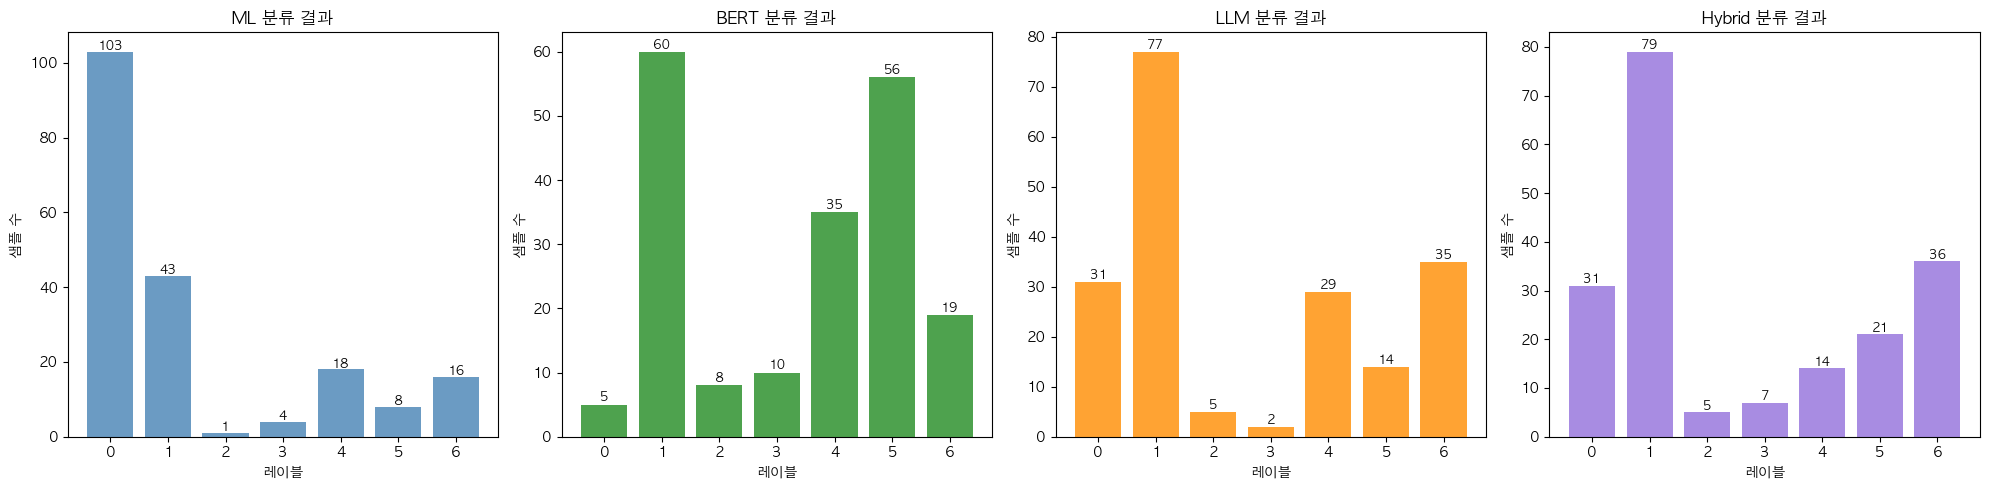

In [126]:
# 분포 비교 차트
if label_cols:
    fig, axes = plt.subplots(1, len(label_cols), figsize=(5 * len(label_cols), 5))
    if len(label_cols) == 1:
        axes = [axes]

    colors = ['steelblue', 'forestgreen', 'darkorange', 'mediumpurple']

    for ax, col, color in zip(axes, label_cols, colors):
        method = col.replace('label_', '')
        counts = result_df[col].value_counts().sort_index()
        bars = ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.8)
        for bar, count in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(count), ha='center', fontsize=9)
        ax.set_xlabel('레이블')
        ax.set_ylabel('샘플 수')
        ax.set_title(f'{method} 분류 결과')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'label_distribution_comparison_{timestamp}.png', dpi=150)
    plt.show()

In [127]:
# ============================================================
# 방식간 일치율 분석
# ============================================================
if len(label_cols) >= 2:
    print("\n=== 방식간 일치율 ===")

    agreement_data = []
    for i, col1 in enumerate(label_cols):
        for col2 in label_cols[i + 1:]:
            method1 = col1.replace('label_', '')
            method2 = col2.replace('label_', '')
            mask = result_df[col1].notna() & result_df[col2].notna()
            if mask.sum() > 0:
                vals1 = result_df.loc[mask, col1]
                vals2 = result_df.loc[mask, col2]
                agreement = (vals1 == vals2).mean()
                kappa = cohen_kappa_score(vals1, vals2)
                agreement_data.append({
                    '비교': f'{method1} vs {method2}',
                    '일치율': f'{agreement:.4f}',
                    'Cohen Kappa': f'{kappa:.4f}',
                    '일치 샘플': int((vals1 == vals2).sum()),
                    '전체 샘플': int(mask.sum())
                })

    agreement_df = pd.DataFrame(agreement_data)
    display(agreement_df)


=== 방식간 일치율 ===


,비교,일치율,Cohen Kappa,일치 샘플,전체 샘플
0,ML vs BERT,0.1813,0.0681,35,193
1,ML vs LLM,0.3109,0.1310,60,193
2,ML vs Hybrid,0.3161,0.1402,61,193
3,BERT vs LLM,0.4870,0.3620,94,193
4,BERT vs Hybrid,0.5855,0.4835,113,193
5,LLM vs Hybrid,0.9016,0.8700,174,193


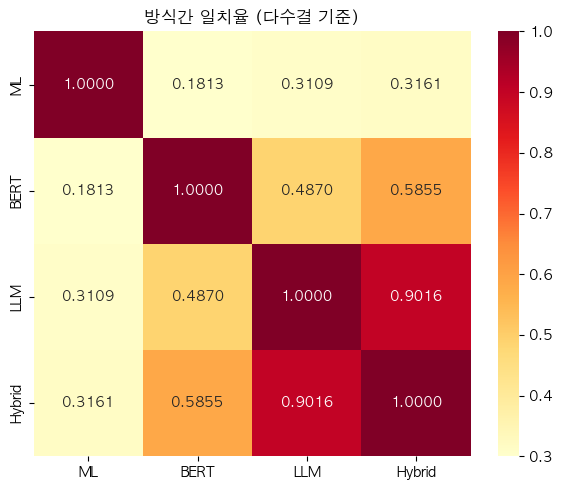

In [128]:
# 방식간 일치율 히트맵
if len(label_cols) >= 2:
    methods = [c.replace('label_', '') for c in label_cols]
    n_methods = len(methods)
    agreement_matrix = np.ones((n_methods, n_methods))

    for i in range(n_methods):
        for j in range(i + 1, n_methods):
            col1 = label_cols[i]
            col2 = label_cols[j]
            mask = result_df[col1].notna() & result_df[col2].notna()
            if mask.sum() > 0:
                agr = (result_df.loc[mask, col1] == result_df.loc[mask, col2]).mean()
                agreement_matrix[i, j] = agr
                agreement_matrix[j, i] = agr

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(agreement_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
                xticklabels=methods, yticklabels=methods,
                vmin=0.3, vmax=1.0, ax=ax)
    ax.set_title('방식간 일치율 (다수결 기준)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'inter_method_agreement_{timestamp}.png', dpi=150)
    plt.show()

## 사람 라벨링 데이터 대비 평가 (핵심 결과)

사람이 직접 라벨링한 정답 데이터와 비교하여 각 모델의 **실제 분류 정확도**를 평가합니다.

> **핵심 질문**: 기존 데이터로 학습된 모델이 완전히 새로운 맥락의 피드백도 올바르게 분류할 수 있는가?

**예상 결과**: 도메인 이동(domain shift)으로 인해 모든 모델의 성능이 기존 데이터 대비 크게 하락할 것으로 예상됩니다. 특히 학습 데이터에 과적합(overfitting)된 ML 모델의 하락이 가장 클 수 있습니다.

In [ ]:
# ============================================================
# 사람 라벨링 데이터 경로 설정 (여기서 수정)
# ============================================================
HUMAN_LABEL_CONFIG = {
    "data_path": "../data/feedback_data.xlsx",  # new_context 시트의 label = 사람 라벨
    "id_column": "id",
    "text_column": "feedback_text",
    "label_column": "label",
}

print("사람 라벨링 데이터 설정:")
for k, v in HUMAN_LABEL_CONFIG.items():
    print(f"  {k}: {v}")

if not HUMAN_LABEL_CONFIG["data_path"]:
    print("\n⚠️  사람 라벨링 데이터 경로가 설정되지 않았습니다!")
    print("    위 'data_path'에 파일 경로를 입력해주세요.")

In [130]:
# ============================================================
# 사람 라벨링 데이터 로드 및 병합
# ============================================================
assert HUMAN_LABEL_CONFIG["data_path"], "data_path를 입력해주세요."

human_path = Path(HUMAN_LABEL_CONFIG["data_path"])
if human_path.suffix == '.csv':
    human_df = pd.read_csv(human_path)
elif human_path.suffix in ['.xlsx', '.xls']:
    human_df = pd.read_excel(human_path, sheet_name='new_context')
else:
    raise ValueError(f"지원하지 않는 파일 형식: {human_path.suffix}")

h_id_col = HUMAN_LABEL_CONFIG["id_column"]
h_label_col = HUMAN_LABEL_CONFIG["label_column"]

print(f"사람 라벨링 데이터 로드: {len(human_df)}개 샘플")
print(f"컬럼: {list(human_df.columns)}")
print(f"\n레이블 분포:")
print(human_df[h_label_col].value_counts().sort_index())

# result_df와 병합
human_df[h_id_col] = human_df[h_id_col].astype(str)
result_df[id_col] = result_df[id_col].astype(str)

eval_df = result_df.merge(
    human_df[[h_id_col, h_label_col]].rename(columns={h_id_col: id_col, h_label_col: 'label_Human'}),
    on=id_col, how='inner'
)

print(f"\n병합 완료: {len(eval_df)}개 샘플 (매칭됨)")
if len(eval_df) < len(result_df):
    print(f"  (원본 {len(result_df)}개 중 {len(result_df) - len(eval_df)}개 미매칭)")

사람 라벨링 데이터 로드: 193개 샘플
컬럼: ['id', 'feedback_text', 'label']

레이블 분포:
label
0    19
1    72
2     6
3    26
4    23
5    24
6    23
Name: count, dtype: int64

병합 완료: 333개 샘플 (매칭됨)


In [131]:
# ============================================================
# 모델별 평가 지표 계산
# ============================================================
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix
)

y_true = eval_df['label_Human'].astype(int)

eval_results = []
model_label_cols = [c for c in eval_df.columns if c.startswith('label_') and c != 'label_Human']

for col in model_label_cols:
    method = col.replace('label_', '')
    mask = eval_df[col].notna()
    if mask.sum() == 0:
        continue

    y_pred = eval_df.loc[mask, col].astype(int)
    y_t = y_true[mask]

    acc = accuracy_score(y_t, y_pred)
    f1 = f1_score(y_t, y_pred, average='macro', zero_division=0)
    f1_w = f1_score(y_t, y_pred, average='weighted', zero_division=0)
    kappa = cohen_kappa_score(y_t, y_pred)

    eval_results.append({
        '방식': method,
        'Accuracy': acc,
        'F1 Macro': f1,
        'F1 Weighted': f1_w,
        'Kappa': kappa,
        '평가 샘플': int(mask.sum()),
    })

eval_results_df = pd.DataFrame(eval_results)

print("=" * 60)
print("모델별 평가 결과 (vs 사람 라벨링)")
print("=" * 60)
display(eval_results_df)

모델별 평가 결과 (vs 사람 라벨링)


,방식,Accuracy,F1 Macro,F1 Weighted,Kappa,평가 샘플
0,ML,0.186186,0.148651,0.182235,0.029228,333
1,BERT,0.453453,0.368478,0.458971,0.316977,333
2,LLM,0.471471,0.389848,0.445440,0.323811,333
3,Hybrid,0.492492,0.421162,0.476204,0.348269,333


In [132]:
# ============================================================
# 모델별 Classification Report
# ============================================================
for col in model_label_cols:
    method = col.replace('label_', '')
    mask = eval_df[col].notna()
    if mask.sum() == 0:
        continue

    y_pred = eval_df.loc[mask, col].astype(int)
    y_t = y_true[mask]

    print(f"\n{'='*50}")
    print(f"Classification Report: {method}")
    print(f"{'='*50}")
    print(classification_report(y_t, y_pred, zero_division=0))


Classification Report: ML
              precision    recall  f1-score   support

           0       0.11      0.70      0.19        27
           1       0.31      0.19      0.23       128
           2       0.00      0.00      0.00        10
           3       0.67      0.09      0.16        45
           4       0.14      0.09      0.11        43
           5       0.20      0.07      0.11        41
           6       0.31      0.21      0.25        39

    accuracy                           0.19       333
   macro avg       0.25      0.19      0.15       333
weighted avg       0.30      0.19      0.18       333


Classification Report: BERT
              precision    recall  f1-score   support

           0       0.44      0.15      0.22        27
           1       0.75      0.59      0.66       128
           2       0.25      0.30      0.27        10
           3       0.59      0.22      0.32        45
           4       0.27      0.40      0.32        43
           5       0.2

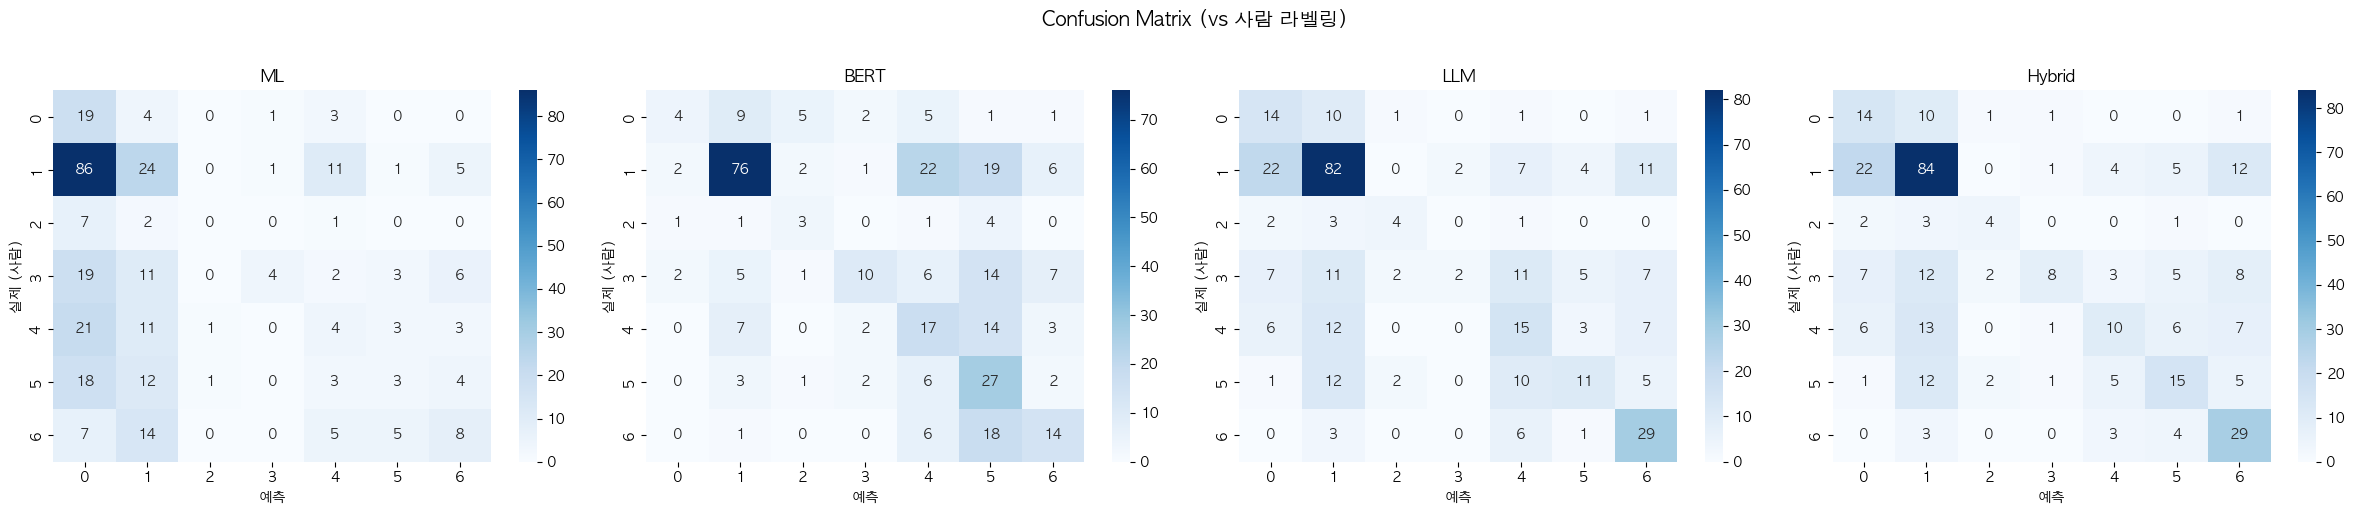

In [133]:
# ============================================================
# Confusion Matrix 시각화
# ============================================================
active_cols = [c for c in model_label_cols if eval_df[c].notna().any()]
n_models = len(active_cols)

if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    all_labels = sorted(y_true.unique())

    for ax, col in zip(axes, active_cols):
        method = col.replace('label_', '')
        mask = eval_df[col].notna()
        y_pred = eval_df.loc[mask, col].astype(int)
        y_t = y_true[mask]

        cm = confusion_matrix(y_t, y_pred, labels=all_labels)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=all_labels, yticklabels=all_labels, ax=ax)
        ax.set_xlabel('예측')
        ax.set_ylabel('실제 (사람)')
        ax.set_title(f'{method}')

    plt.suptitle('Confusion Matrix (vs 사람 라벨링)', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'confusion_matrices_{timestamp}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [134]:
# ============================================================
# 평가 결과 저장
# ============================================================
eval_output_path = OUTPUT_DIR / f'evaluation_results_{timestamp}.csv'
eval_results_df.to_csv(eval_output_path, index=False)

print(f"\n평가 결과 저장: {eval_output_path}")


평가 결과 저장: results/evaluation_results_20260209_223409.csv


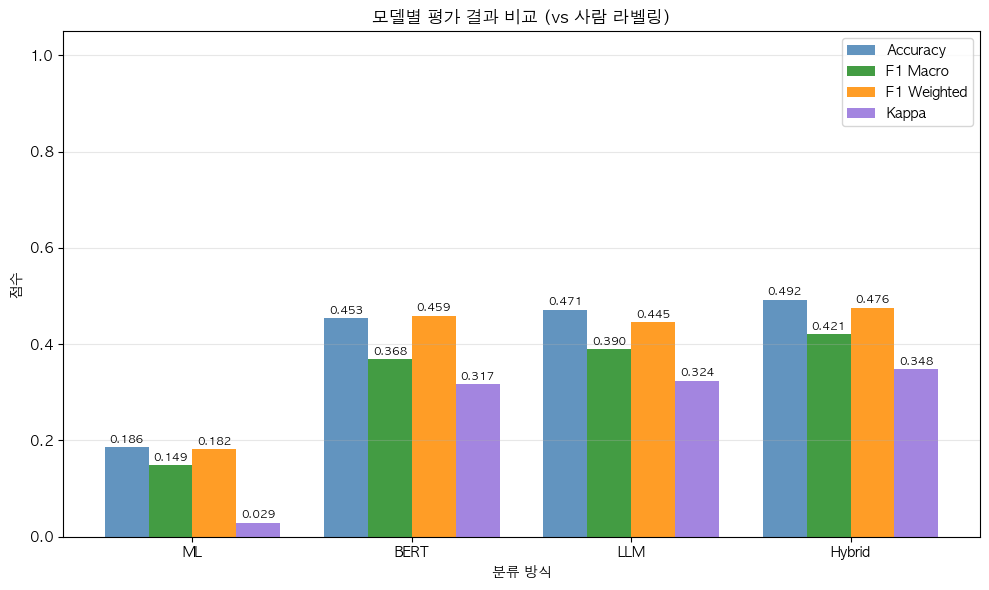

In [135]:
# ============================================================
# 평가 결과 비교 차트
# ============================================================
if len(eval_results_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    metrics_to_plot = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Kappa']
    x = np.arange(len(eval_results_df))
    width = 0.2
    colors = ['steelblue', 'forestgreen', 'darkorange', 'mediumpurple']

    for i, metric in enumerate(metrics_to_plot):
        vals = eval_results_df[metric].values
        bars = ax.bar(x + i * width, vals, width, label=metric, color=colors[i], alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('분류 방식')
    ax.set_ylabel('점수')
    ax.set_title('모델별 평가 결과 비교 (vs 사람 라벨링)')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(eval_results_df['방식'].values)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'evaluation_comparison_{timestamp}.png', dpi=150)
    plt.show()

---
## 완료

In [136]:
print("\n" + "=" * 60)
print("전체 작업 완료!")
print("=" * 60)
print(f"\n[자동 선택된 모델]")
print(f"  ML:     {best_ml_info['display_name']}")
print(f"  BERT:   {best_bert_info['model_name']}")
print(f"  LLM:    {best_llm_info['model']} + {best_llm_info['prompt']}")
print(f"  Hybrid: LLM + BERT (Label 3,4,5 재분류)")
print(f"\n[반복 실행]")
print(f"  {N_RUNS}회 반복 완료")
print(f"\n[저장 파일]")
print(f"  최종 결과: {output_path}")
print(f"  상세 예측: {detail_path}")
if HUMAN_LABEL_CONFIG['data_path']:
    print(f"  평가 결과: {eval_output_path}")
print(f"\n완료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


전체 작업 완료!

[자동 선택된 모델]
  ML:     SVM (Linear)
  BERT:   KLUE-BERT_seed44
  LLM:    GPT-4o + P4_CoT_Few_Context
  Hybrid: LLM + BERT (Label 3,4,5 재분류)

[반복 실행]
  1회 반복 완료

[저장 파일]
  최종 결과: results/classified_data_new_ALL_20260209_223409.xlsx
  상세 예측: results/detailed_predictions_20260209_223409.csv
  평가 결과: results/evaluation_results_20260209_223409.csv

완료 시간: 2026-02-09 22:34:11
